In [132]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [133]:
# Load Dataset

df = pd.read_csv("C:\\Users\DELL\OneDrive\Desktop\House Price Prediction\data\Bengaluru_House_Data.csv")

df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [134]:
df.shape


(13320, 9)

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [136]:
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [137]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


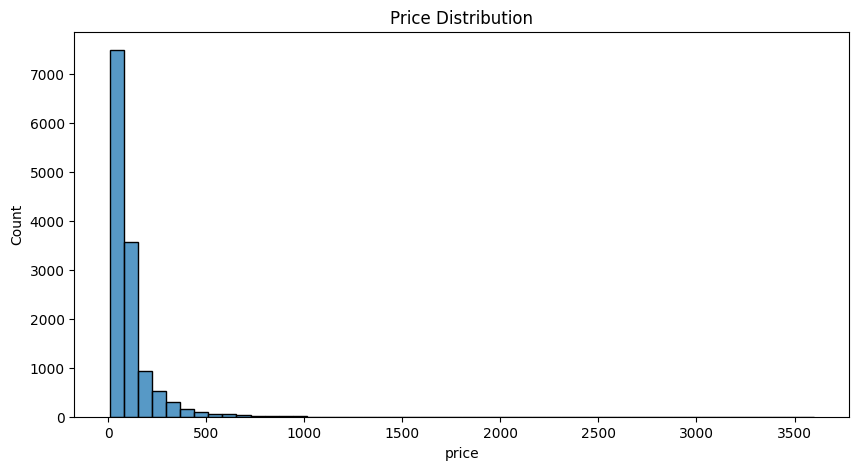

In [138]:
# ---------------------------------------------
# EDA
# ---------------------------------------------

# Price Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50)

plt.title("Price Distribution")

plt.show()


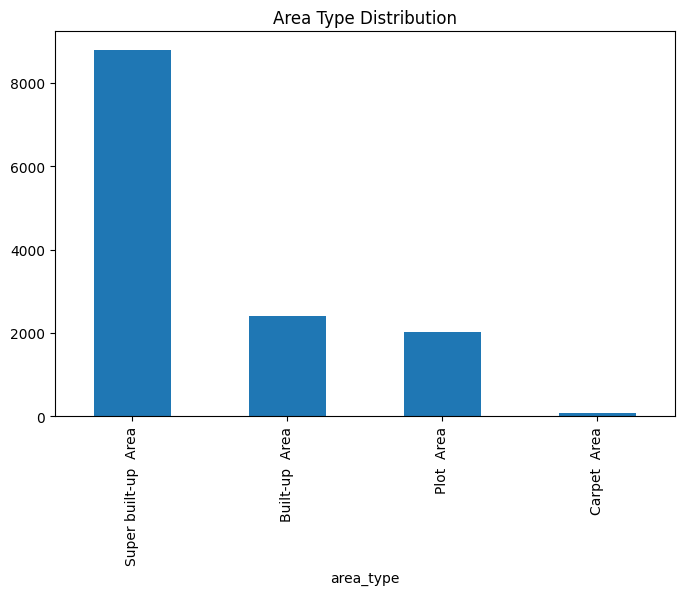

In [139]:
# Area Type Distribution

plt.figure(figsize=(8,5))

df['area_type'].value_counts().plot(kind='bar')

plt.title("Area Type Distribution")

plt.show()

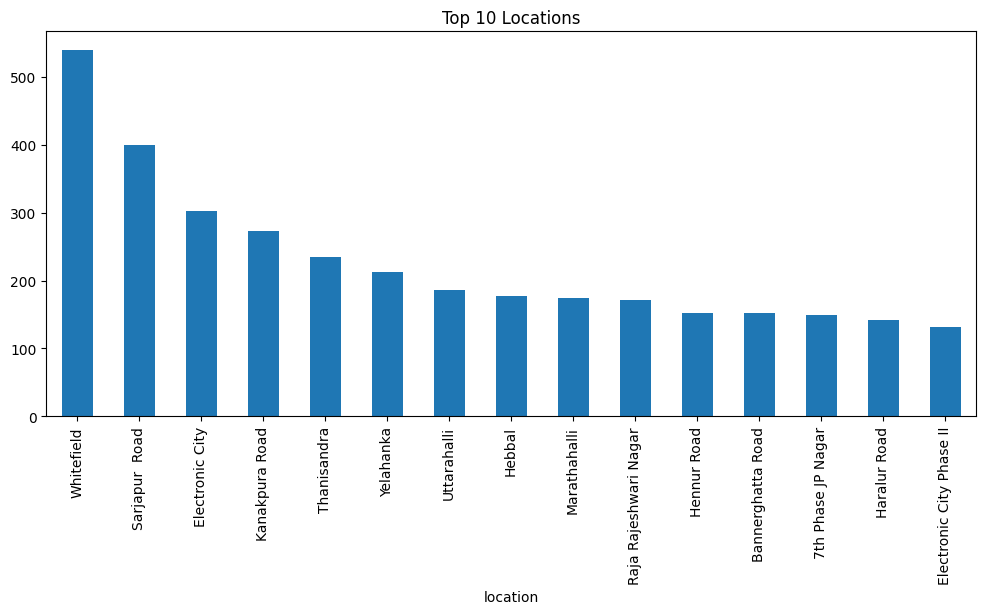

In [140]:
plt.figure(figsize=(12,5))

df['location'].value_counts().head(15).plot(kind='bar')

plt.title("Top 10 Locations")

plt.show()


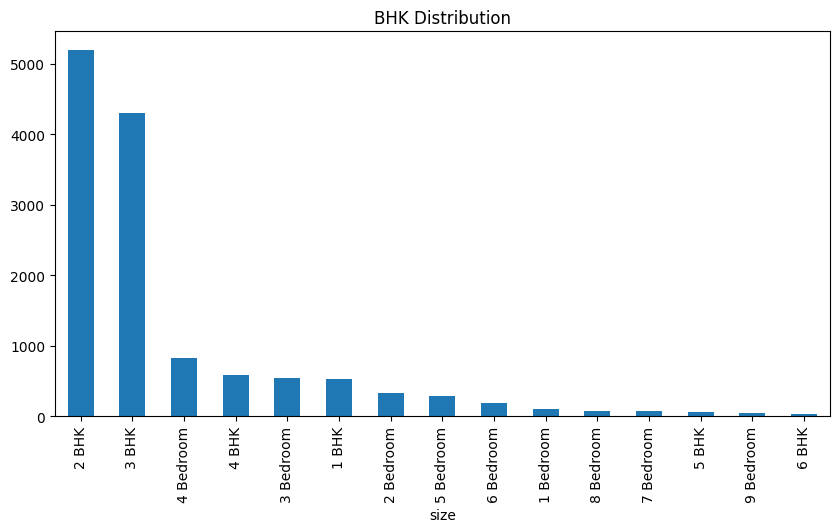

In [141]:

# BHK Distribution

plt.figure(figsize=(10,5))

df['size'].value_counts().head(15).plot(kind='bar')

plt.title("BHK Distribution")

plt.show()

In [142]:
# Data Cleaning
# ---------------------------------------------

# Drop Society Column

df.drop('society', axis=1, inplace=True)

# Remove Null Values

df.dropna(inplace=True)

In [143]:
# ---------------------------------------------
# Feature Engineering
# ---------------------------------------------

# Create BHK Column

df['bhk'] = df['size'].apply(
    lambda x: int(x.split(' ')[0])
)

In [144]:
# Clean total_sqft Column

def convert_sqft(x):

    tokens = x.split('-')

    if len(tokens) == 2:

        return (
            float(tokens[0]) +
            float(tokens[1])
        ) / 2

    try:
        return float(x)

    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)


In [145]:
# Remove Null Sqft Rows

df = df[df['total_sqft'].notnull()]

# Clean Location Names

df['location'] = df['location'].apply(
    lambda x: x.strip()
)

In [146]:
# Top Locations

location_stats = df['location'].value_counts()

top_locations = location_stats[
    location_stats > 15
].index

In [147]:
# Replace Rare Locations

df['location'] = df['location'].apply(
    lambda x: x if x in top_locations else 'other'
)


In [148]:
# ---------------------------------------------
# Outlier Removal
# ---------------------------------------------

df = df[
    df['total_sqft'] / df['bhk'] >= 300
]

# ---------------------------------------------
# Price Per Sqft
# ---------------------------------------------

df['price_per_sqft'] = (
    df['price'] * 100000
) / df['total_sqft']

# ---------------------------------------------
# Remove Global Outliers
# ---------------------------------------------

df = df[
    (df['price_per_sqft'] > 1000) &
    (df['price_per_sqft'] < 30000)
]

In [149]:
def remove_pps_outliers(dataframe):

    final_df = pd.DataFrame()

    for location, subdf in dataframe.groupby('location'):

        mean = np.mean(subdf.price_per_sqft)

        std = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (
                subdf.price_per_sqft > (mean - std)
            ) &
            (
                subdf.price_per_sqft <= (mean + std)
            )
        ]

        final_df = pd.concat(
            [final_df, reduced_df],
            ignore_index=True
        )

    return final_df



In [150]:
df = remove_pps_outliers(df)

In [151]:
# ---------------------------------------------
# Remove BHK Outliers
# ---------------------------------------------

def remove_bhk_outliers(df):

    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):

            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):

            stats = bhk_stats.get(bhk-1)

            if stats and stats['count'] > 5:

                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[
                        bhk_df.price_per_sqft <
                        stats['mean']
                    ].index.values
                )

    return df.drop(exclude_indices, axis='index')


In [152]:

df = remove_bhk_outliers(df)

In [114]:
# ---------------------------------------------
# Remove Extreme Bathroom Outliers
# ---------------------------------------------

df = df[df['bath'] < df['bhk'] + 2]

# ---------------------------------------------
# Keep Important Columns
# ---------------------------------------------

df.drop(
    ['size'],
    axis=1,
    inplace=True
)

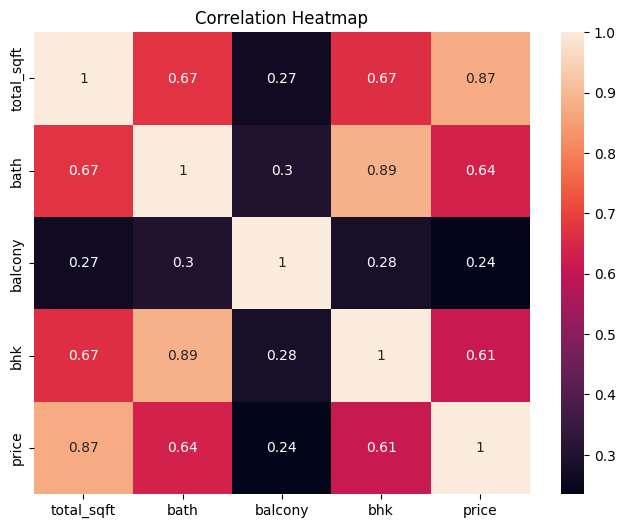

In [115]:
# ---------------------------------------------
# Correlation Heatmap
# ---------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            'total_sqft',
            'bath',
            'balcony',
            'bhk',
            'price'
        ]
    ].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

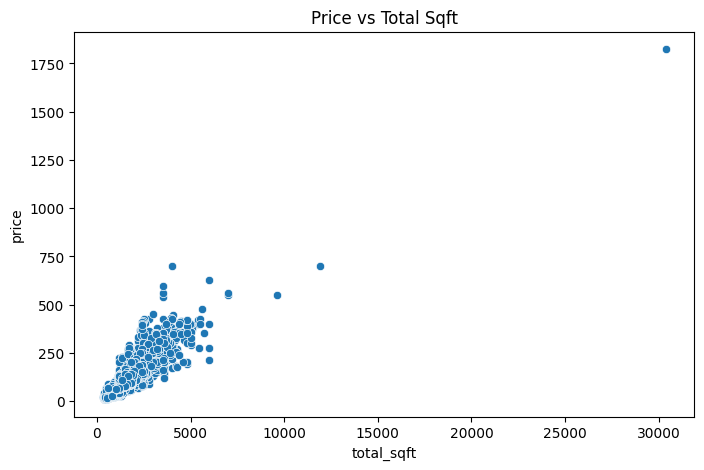

In [116]:
# Price vs Sqft

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['total_sqft'],
    y=df['price']
)

plt.title("Price vs Total Sqft")

plt.show()

In [124]:
# Remove Extreme Bathroom Outliers
# ---------------------------------------------

df = df[df['bath'] < df['bhk'] + 2]


In [127]:
# ---------------------------------------------
# One Hot Encoding
# ---------------------------------------------

df = pd.get_dummies(
    df,
    columns=[
        'location',
        'area_type'
    ]
)


KeyError: "None of [Index(['location', 'area_type'], dtype='str')] are in the [columns]"

In [128]:
# ---------------------------------------------
# Features and Target
# ---------------------------------------------

X = df.drop('price', axis=1)

y = df['price']


In [129]:
# ---------------------------------------------
# Train Test Split
# ---------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [130]:
# ---------------------------------------------
# Model 1 - Linear Regression
# ---------------------------------------------

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

ValueError: could not convert string to float: 'Ready To Move'

In [76]:
# ---------------------------------------------
# Model 2 - Decision Tree
# ---------------------------------------------

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)


In [77]:
# ---------------------------------------------
# Model 3 - Random Forest
# ---------------------------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)


In [78]:
# ---------------------------------------------
# Model Comparison
# ---------------------------------------------

comparison = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ],

    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae
    ],

    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ]

})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.451648,38.617087,94.928023
1,Decision Tree,0.212596,34.894966,113.753206
2,Random Forest,0.571200,28.461893,83.944526


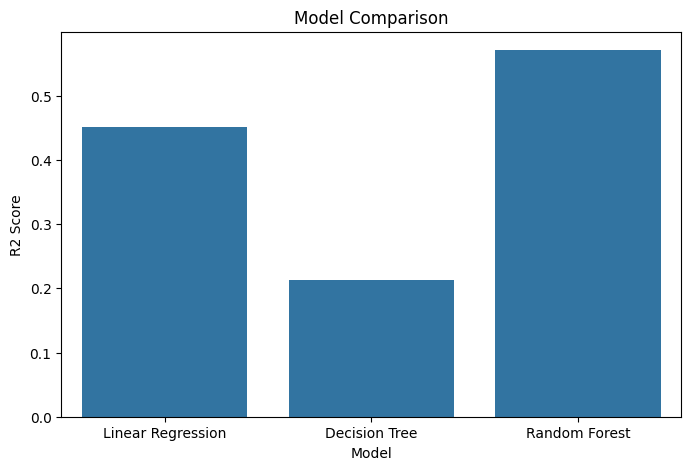

In [79]:
# Model Comparison Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=comparison
)

plt.title("Model Comparison")

plt.show()

In [80]:
# ---------------------------------------------
# Best Model
# ---------------------------------------------

best_model = rf

In [81]:
# Save Model

joblib.dump(
    best_model,
    "model.pkl"
)

['model.pkl']

In [82]:
# Save Columns

columns = {
    'data_columns': [col.lower() for col in X.columns]
}

with open("columns.json", "w") as f:

    f.write(json.dumps(columns))

In [83]:
# Sample Prediction
# ---------------------------------------------

sample_data = X.iloc[0:1]

best_model.predict(sample_data)

array([47.04941756])

In [153]:
# ---------------------------------------------
# Remove Invalid Sqft/BHK
# ---------------------------------------------

df = df[
    df['total_sqft'] / df['bhk'] >= 300
]

# ---------------------------------------------
# Create Price Per Sqft
# ---------------------------------------------

df['price_per_sqft'] = (
    df['price'] * 100000
) / df['total_sqft']

# ---------------------------------------------
# Remove Global Outliers
# ---------------------------------------------

df = df[
    (df['price_per_sqft'] > 1000) &
    (df['price_per_sqft'] < 30000)
]

# ---------------------------------------------
# Remove Location Wise Outliers
# ---------------------------------------------

def remove_pps_outliers(data):

    final_df = pd.DataFrame()

    for location, subdf in data.groupby('location'):

        mean = np.mean(subdf['price_per_sqft'])

        std = np.std(subdf['price_per_sqft'])

        reduced_df = subdf[
            (
                subdf['price_per_sqft'] >= (mean - std)
            ) &
            (
                subdf['price_per_sqft'] <= (mean + std)
            )
        ]

        final_df = pd.concat(
            [final_df, reduced_df],
            ignore_index=True
        )

    return final_df

df = remove_pps_outliers(df)

# ---------------------------------------------
# Remove BHK Outliers
# ---------------------------------------------

def remove_bhk_outliers(data):

    exclude_indices = np.array([])

    for location, location_df in data.groupby('location'):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):

            bhk_stats[bhk] = {

                'mean': np.mean(
                    bhk_df['price_per_sqft']
                ),

                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):

            stats = bhk_stats.get(bhk - 1)

            if stats and stats['count'] > 5:

                exclude_indices = np.append(

                    exclude_indices,

                    bhk_df[
                        bhk_df['price_per_sqft'] <
                        stats['mean']
                    ].index.values
                )

    return data.drop(
        exclude_indices,
        axis='index'
    )

df = remove_bhk_outliers(df)

# ---------------------------------------------
# Remove Bathroom Outliers
# ---------------------------------------------

df = df[
    df['bath'] < df['bhk'] + 2
]

# ---------------------------------------------
# Drop Unused Columns
# ---------------------------------------------

df.drop(
    [
        'size',
        'availability',
        'price_per_sqft'
    ],
    axis=1,
    inplace=True
)

# ---------------------------------------------
# NOW APPLY ONE HOT ENCODING
# ---------------------------------------------

df = pd.get_dummies(
    df,
    columns=[
        'location',
        'area_type'
    ]
)

# ---------------------------------------------
# Features and Target
# ---------------------------------------------

X = df.drop('price', axis=1)

y = df['price']

# ---------------------------------------------
# Train Test Split
# ---------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------
# Improved Random Forest Model
# ---------------------------------------------

rf = RandomForestRegressor(

    n_estimators=500,

    max_depth=30,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1
)

rf.fit(X_train, y_train)

# ---------------------------------------------
# Prediction
# ---------------------------------------------

rf_pred = rf.predict(X_test)

# ---------------------------------------------
# Accuracy
# ---------------------------------------------

r2 = r2_score(y_test, rf_pred)

mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("R2 Score :", r2)

print("MAE :", mae)

print("RMSE :", rmse)

# ---------------------------------------------
# Save Model
# ---------------------------------------------

joblib.dump(
    rf,
    "model.pkl"
)

# ---------------------------------------------
# Save Columns
# ---------------------------------------------

columns = {
    'data_columns': [col.lower() for col in X.columns]
}

with open("columns.json", "w") as f:

    f.write(json.dumps(columns))

R2 Score : 0.8858084212485462
MAE : 10.857168295715143
RMSE : 20.75494347917235
